# MAT 125 Demographic Success Analysis

**Motivational Question:** *What populations are less successful in MAT 125?*

This notebook is an introduction to loading, cleaning, and exploring data in Python. We will work through one of the core motivational questions for DataFest 2026 using real enrollment data from NAU's Lumberjack Mathematics Center.

By the end, you will know how to:
- Load a CSV into a pandas DataFrame
- Inspect and clean your data
- Engineer a new feature (pass/fail)
- Compute group-level statistics
- Build bar charts, KDE plots, and heatmaps

**Data covers:** Fall 2024 (Term 1247) and Spring 2025 (Term 1251)

## 1. Imports

We start by importing every library we will use. Doing this at the top of the notebook is best practice — it makes dependencies clear and avoids surprises mid-analysis.

| Library | Purpose |
|---|---|
| `pandas` | Load and manipulate tabular data |
| `matplotlib` | Low-level plotting engine |
| `seaborn` | High-level statistical plots built on matplotlib |
| `warnings` | Suppress noisy but harmless library warnings |

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Data

`pd.read_csv()` reads a comma-separated file and returns a **DataFrame** — essentially a spreadsheet object in Python.

- The path is relative to where this notebook lives.
- `.shape` returns `(rows, columns)` — a quick sanity check that everything loaded.

In [2]:
sis = pd.read_csv("Cleaned_For_DataSci/SIS.csv")

print(f"Shape: {sis.shape[0]} rows × {sis.shape[1]} columns")

Shape: 2320 rows × 45 columns


## 3. Data Inspection

Before touching the data, always look at it. Three useful checks:

1. **`.dtypes`** — what type did pandas assign to each column?
2. **`.isnull().sum()`** — how many missing values are in each column?
3. **`.value_counts()`** — what values appear in key categorical columns?

Understanding the data structure helps you avoid bugs later.

In [3]:
# Data types and null counts side-by-side
inspection = pd.DataFrame({
    "dtype":      sis.dtypes,
    "null_count": sis.isnull().sum()
})
print(inspection.to_string())

                                dtype  null_count
Identifier                      int64           0
Term                          float64          48
Class                          object          48
Class.Nbr                     float64          48
Section                       float64          48
Primary.Instruction.Section   float64        1445
Class.Description              object        1445
Official.Grade                 object         612
Status.Cd                      object        1445
Status.Reason                  object          48
Enrolled.Hours                float64        1445
Add.Date                       object        1445
IPEDS.Ethnicity                object          48
X1st.Gen.College.Std.Flag      object        1445
Mail.City                      object        1449
Mail.State.Cd                  object        1449
Mail.Country                   object        1449
Home.City                      object        1451
Home.State.Cd                  object        1451


In [4]:
# What grade values actually exist in the data?
# Note: a space character ' ' is NOT the same as NaN!
print("Official.Grade value counts (raw):")
print(sis["Official.Grade"].value_counts(dropna=False))

Official.Grade value counts (raw):
Official.Grade
NaN    612
A      418
       287
B      271
C      264
W      195
F      183
D       90
Name: count, dtype: int64


In [5]:
# Quick look at other key columns
for col in ["Sex", "IPEDS.Ethnicity", "X1st.Gen.College.Std.Flag",
            "Instruction.Mode", "Academic.Level.Begin.of.Term", "Term"]:
    print(f"\n--- {col} ---")
    print(sis[col].value_counts(dropna=False))


--- Sex ---
Sex
Female     1236
Male       1030
NaN          48
Unknown       6
Name: count, dtype: int64

--- IPEDS.Ethnicity ---
IPEDS.Ethnicity
White                             1179
Hispanic/Latino                    614
Two or More                        162
American Indian/Alaska Native      128
Black/African American              84
Asian                               50
NaN                                 48
Not Specified                       39
International                       13
Native Hawaiian/Oth Pac Island       3
Name: count, dtype: int64

--- X1st.Gen.College.Std.Flag ---
X1st.Gen.College.Std.Flag
NaN    1445
N       528
Y       339
U         8
Name: count, dtype: int64

--- Instruction.Mode ---
Instruction.Mode
In Person    2211
Online         61
NaN            48
Name: count, dtype: int64

--- Academic.Level.Begin.of.Term ---
Academic.Level.Begin.of.Term
Freshman                    1603
Sophomore                    451
Junior                       163
NaN         

## 4. Feature Engineering

**Feature engineering** means creating new columns from existing ones that are more useful for analysis.

We need to do two things:

1. **Filter out blank grades.** Students who dropped before the grading window have `Official.Grade = " "` (a space string). These are not the same as students who failed — they never received a grade. We exclude them.

2. **Create a `Passed` column.** A student passes if they earned an A, B, or C. D, F, and W are considered not passing.

> **Key terms:**
> - `str.strip()` removes leading/trailing whitespace from strings
> - `.isin()` checks whether each value belongs to a set
> - A boolean column (`True`/`False`) can be cast to integers (1/0) with `.astype(int)`

In [6]:
# Strip whitespace from grade column
sis["Official.Grade"] = sis["Official.Grade"].str.strip()

# Exclude rows with no grade (dropped before grading)
graded = sis[sis["Official.Grade"] != ""].copy()

print(f"Original rows : {len(sis)}")
print(f"After removing blank grades: {len(graded)}")
print(f"Excluded      : {len(sis) - len(graded)} rows")

Original rows : 2320
After removing blank grades: 2033
Excluded      : 287 rows


In [9]:
# Define passing grades
PASS_GRADES = {"A", "B", "C"}

# Create boolean Passed column, then numeric version (1 = passed, 0 = not passed)
graded["Passed"]     = graded["Official.Grade"].isin(PASS_GRADES)
graded["Passed_int"] = graded["Passed"].astype(int)

# Verify: check grade ↔ Passed mapping
print(graded.groupby("Official.Grade")["Passed"].first().to_string())

Official.Grade
A     True
B     True
C     True
D    False
F    False
W    False


In [10]:
# Overall pass rate — our reference line for all charts
overall_pass_rate = graded["Passed_int"].mean() * 100
print(f"Overall MAT 125 pass rate: {overall_pass_rate:.1f}%")

Overall MAT 125 pass rate: 46.9%


## 5. Helper Function

We will make the same calculation six times (once per demographic). Rather than copy-pasting code, we write a **reusable function**.

The function:
- Groups the data by any column you pass in
- Computes pass rate (%) and student count per group
- Filters out groups with fewer than `min_students` to avoid misleading percentages from tiny samples

In [12]:
def pass_rate_by(df, col, min_students=10):
    """
    Compute pass rate (%) grouped by a categorical column.

    Parameters
    ----------
    df           : DataFrame containing 'Passed_int' column
    col          : column name to group by
    min_students : minimum group size to include (default 10)

    Returns
    -------
    DataFrame with columns [col, 'pass_rate', 'n']
    """
    result = (
        df.groupby(col)["Passed_int"]
          .agg(pass_rate="mean", n="count")
          .reset_index()
    )
    result["pass_rate"] = result["pass_rate"] * 100  # convert to %
    result = result[result["n"] >= min_students]      # drop small groups
    return result.sort_values("pass_rate")

## 6. Demographic Analyses

For each demographic variable we will:
1. Call `pass_rate_by()` to get the summary table
2. Print the table
3. Make a horizontal bar chart with the overall pass rate shown as a red dashed reference line

The bar annotation `n=XX` tells us how many students are in each group, so we can judge reliability.

### 6a. Sex

   Sex  pass_rate    n
  Male  47.130243  906
Female  48.789572 1074


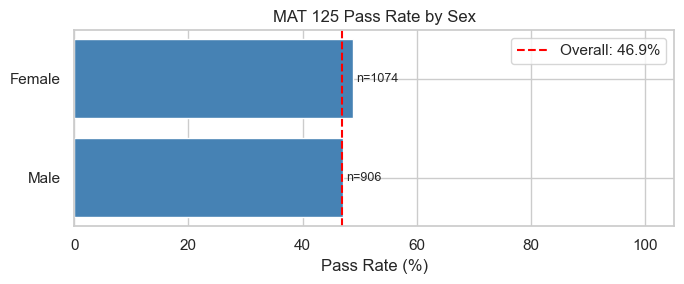

In [13]:
sex_df = pass_rate_by(graded, "Sex")
print(sex_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(sex_df["Sex"], sex_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, sex_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by Sex")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

### 6b. IPEDS Ethnicity

              IPEDS.Ethnicity  pass_rate    n
                Not Specified  40.000000   35
                        Asian  40.909091   44
American Indian/Alaska Native  43.362832  113
       Black/African American  44.736842   76
                  Two or More  46.666667  150
                        White  48.499516 1033
              Hispanic/Latino  49.518304  519


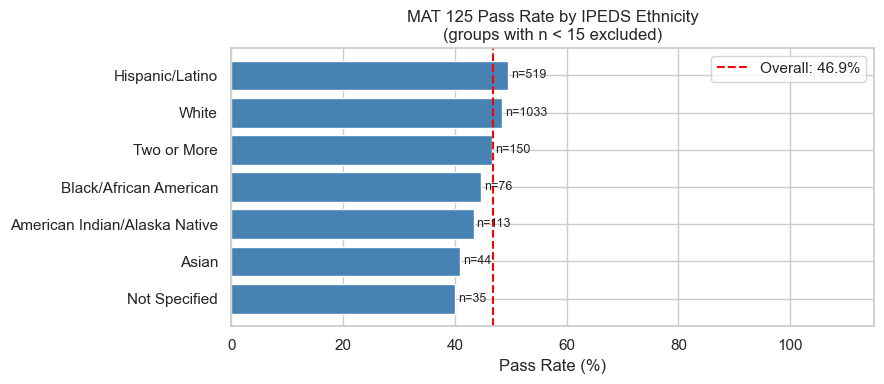

In [14]:
# Use min_students=15 for ethnicity — small groups can create very misleading percentages
eth_df = pass_rate_by(graded, "IPEDS.Ethnicity", min_students=15)
print(eth_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(eth_df["IPEDS.Ethnicity"], eth_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, eth_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by IPEDS Ethnicity\n(groups with n < 15 excluded)")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

### 6c. First-Generation College Student Status

The column `X1st.Gen.College.Std.Flag` is `Y` if the student is the first in their family to attend college, `N` otherwise.

X1st.Gen.College.Std.Flag  pass_rate   n
                First-Gen  54.066986 209
            Non-First-Gen  58.021390 374


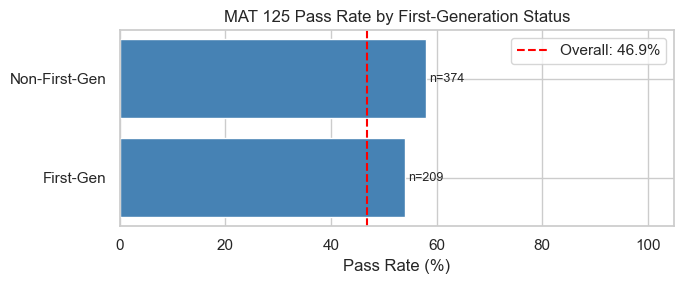

In [15]:
gen_df = pass_rate_by(graded, "X1st.Gen.College.Std.Flag")
# Rename Y/N to be more readable
gen_df["X1st.Gen.College.Std.Flag"] = gen_df["X1st.Gen.College.Std.Flag"].map(
    {"Y": "First-Gen", "N": "Non-First-Gen"}
).fillna(gen_df["X1st.Gen.College.Std.Flag"])
print(gen_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(gen_df["X1st.Gen.College.Std.Flag"], gen_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, gen_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by First-Generation Status")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

### 6d. Instruction Mode

How the course was delivered — in-person, online, hybrid, etc.

Instruction.Mode  pass_rate    n
       In Person  47.614161 1949
          Online  69.444444   36


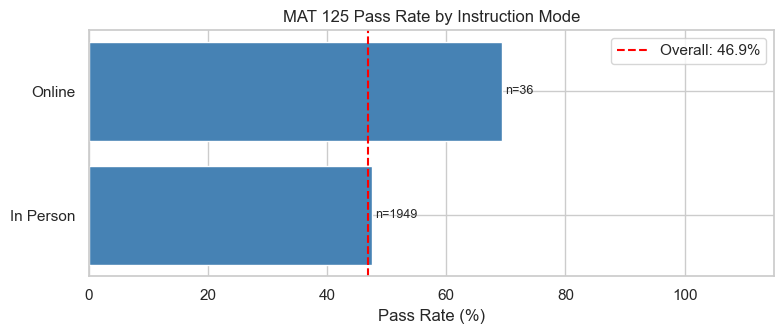

In [16]:
mode_df = pass_rate_by(graded, "Instruction.Mode")
print(mode_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(mode_df["Instruction.Mode"], mode_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, mode_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by Instruction Mode")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

### 6e. Academic Level

A student's year in school at the beginning of the term. We apply a custom sort so the chart reads Freshman → Senior.

Academic.Level.Begin.of.Term  pass_rate    n
                    Freshman  48.421053 1425
                   Sophomore  44.210526  380
                      Junior  51.470588  136
                      Senior  55.555556   36


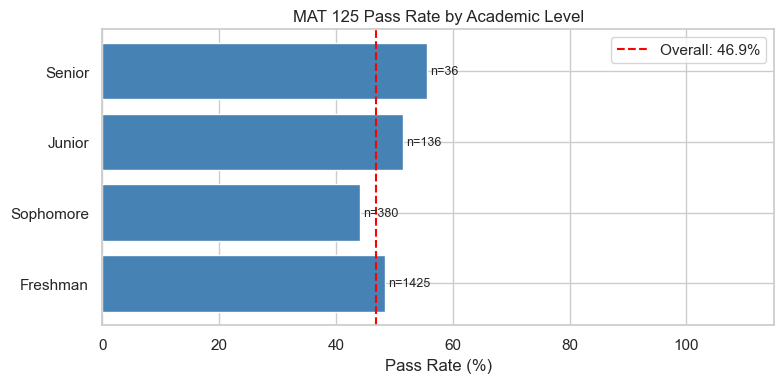

In [17]:
level_order = ["Freshman", "Sophomore", "Junior", "Senior"]

level_df = pass_rate_by(graded, "Academic.Level.Begin.of.Term")
# Apply custom sort: keep only known levels, in order
level_df = level_df[level_df["Academic.Level.Begin.of.Term"].isin(level_order)]
level_df = level_df.set_index("Academic.Level.Begin.of.Term").loc[
    [l for l in level_order if l in level_df["Academic.Level.Begin.of.Term"].values]
].reset_index()
print(level_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(level_df["Academic.Level.Begin.of.Term"], level_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, level_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by Academic Level")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

### 6f. Age Groups

`pd.cut()` bins a continuous variable into labeled intervals. This converts raw age into a readable category.

Age.Group  pass_rate    n
    20-22  37.354988  431
    17-19  50.738255 1490
    23-25  53.333333   30
      26+  58.823529   34


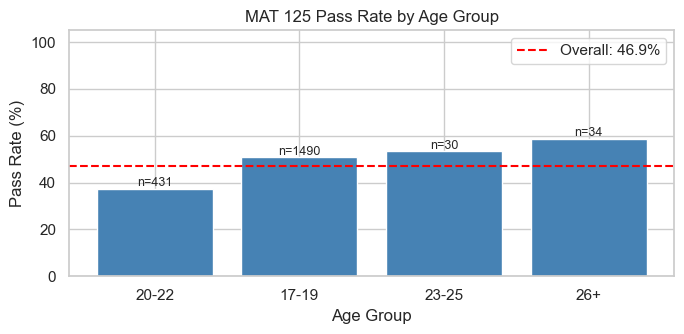

In [19]:
graded["Age.Group"] = pd.cut(
    graded["Age"],
    bins=[0, 19, 22, 25, 100],
    labels=["17-19", "20-22", "23-25", "26+"]
)

age_df = pass_rate_by(graded, "Age.Group")
print(age_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
# Vertical bars — short labels fit better this way
bars = ax.bar(age_df["Age.Group"].astype(str), age_df["pass_rate"], color="steelblue")
ax.axhline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, age_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"n={int(row['n'])}", ha="center", fontsize=9)
ax.set_xlabel("Age Group")
ax.set_ylabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by Age Group")
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

## 7. GPA Distribution: Passed vs. Failed

Does prior GPA (`Cum.GPA`) predict success in MAT 125? We use two views:

- **KDE (Kernel Density Estimate):** a smoothed histogram showing the shape of the distribution
- **Boxplot:** shows median, interquartile range, and outliers side-by-side

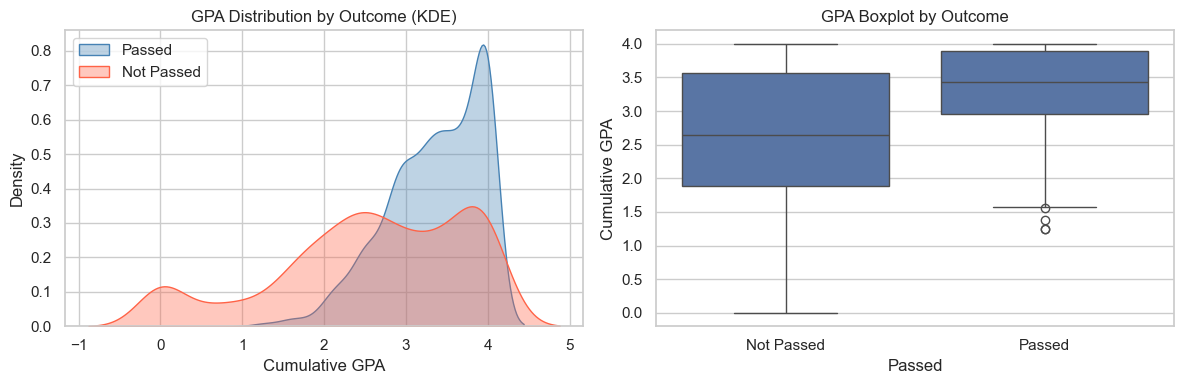

In [21]:
gpa_data = graded.dropna(subset=["Cum.GPA"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE overlay
for passed, label, color in [(True, "Passed", "steelblue"), (False, "Not Passed", "tomato")]:
    subset = gpa_data[gpa_data["Passed"] == passed]["Cum.GPA"]
    sns.kdeplot(subset, ax=axes[0], label=label, color=color, fill=True, alpha=0.35)
axes[0].set_xlabel("Cumulative GPA")
axes[0].set_title("GPA Distribution by Outcome (KDE)")
axes[0].legend()

# Boxplot
sns.boxplot(
    data=gpa_data,
    x="Passed",
    y="Cum.GPA",
    ax=axes[1]
)
axes[1].set_xticklabels(["Not Passed", "Passed"])
axes[1].set_title("GPA Boxplot by Outcome")
axes[1].set_ylabel("Cumulative GPA")

plt.tight_layout()
plt.show()

## 8. Term Comparison: Fall 2024 vs. Spring 2025

Are outcomes different between semesters? Seasonal effects (workload, course offering mix) can influence pass rates.

 Term.Label  pass_rate    n
  Fall 2024  44.237652 1397
Spring 2025  56.972789  588


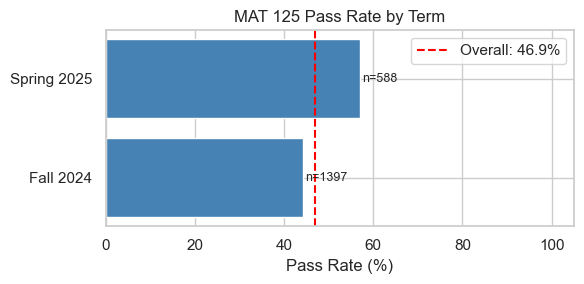

In [22]:
# Map term codes to readable labels
graded["Term.Label"] = graded["Term"].map({1247: "Fall 2024", 1251: "Spring 2025"})

term_df = pass_rate_by(graded, "Term.Label")
print(term_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(term_df["Term.Label"], term_df["pass_rate"], color="steelblue")
ax.axvline(overall_pass_rate, color="red", linestyle="--", label=f"Overall: {overall_pass_rate:.1f}%")
for bar, (_, row) in zip(bars, term_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("MAT 125 Pass Rate by Term")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Intersectional Heatmap: Ethnicity × First-Gen Status

Looking at demographics one at a time can hide important patterns. An **intersectional** view shows how two variables interact.

Cells with fewer than 10 students are masked (shown in gray) to prevent drawing conclusions from too little data.

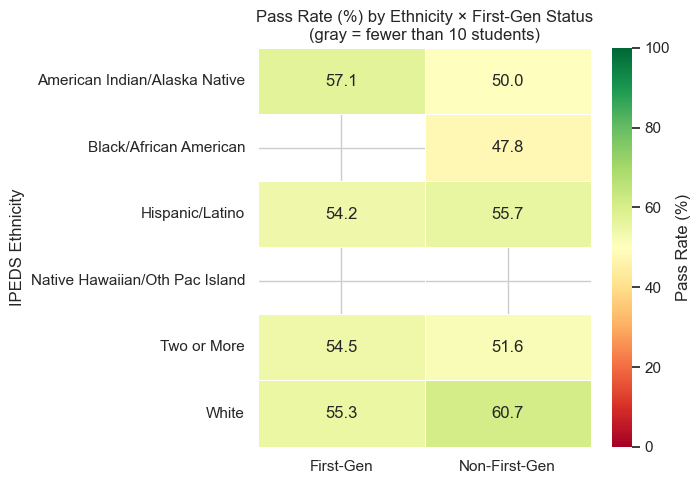

In [23]:
MIN_CELL = 10

# Recode first-gen flag
graded["FirstGen.Label"] = graded["X1st.Gen.College.Std.Flag"].map(
    {"Y": "First-Gen", "N": "Non-First-Gen"}
)

# Pivot: rows = ethnicity, cols = first-gen, values = pass rate
heat_rate = graded.pivot_table(
    index="IPEDS.Ethnicity",
    columns="FirstGen.Label",
    values="Passed_int",
    aggfunc="mean"
) * 100

# Counts pivot for masking
heat_n = graded.pivot_table(
    index="IPEDS.Ethnicity",
    columns="FirstGen.Label",
    values="Passed_int",
    aggfunc="count"
)

mask = heat_n < MIN_CELL

# Drop rows where both cells are masked
keep_rows = ~mask.all(axis=1)
heat_rate = heat_rate[keep_rows]
mask       = mask[keep_rows]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    heat_rate,
    mask=mask,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=0, vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Pass Rate (%)"}
)
ax.set_title(f"Pass Rate (%) by Ethnicity × First-Gen Status\n(gray = fewer than {MIN_CELL} students)")
ax.set_ylabel("IPEDS Ethnicity")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 10. Full Grade Distribution

Instead of collapsing to pass/fail, here we show the complete breakdown (A, B, C, D, F, W) as stacked horizontal bars. This lets us see *how* students fail — did they withdraw (W) or complete but earn a low grade (D/F)?

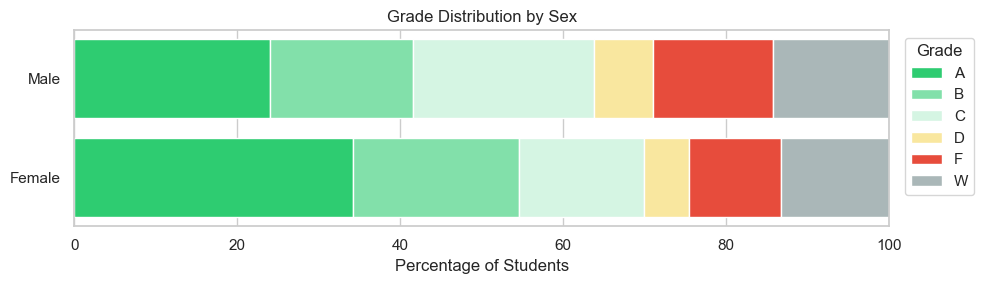

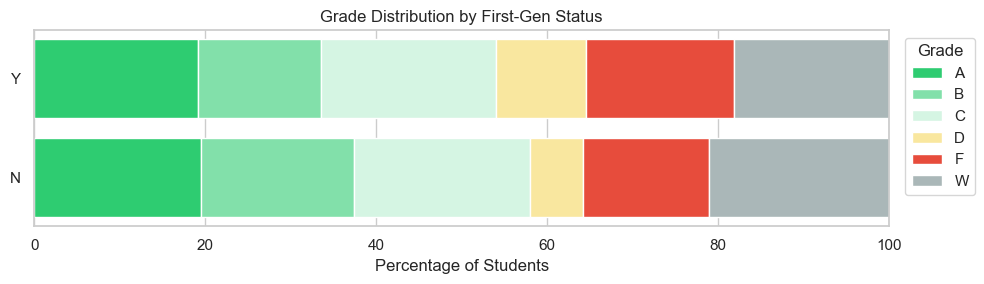

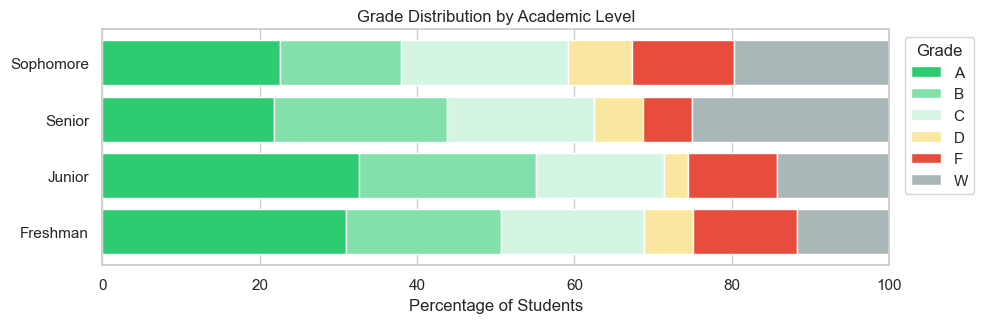

In [24]:
GRADE_ORDER  = ["A", "B", "C", "D", "F", "W"]
GRADE_COLORS = ["#2ecc71", "#82e0aa", "#d5f5e3", "#f9e79f", "#e74c3c", "#aab7b8"]

def grade_dist_chart(df, group_col, title, min_n=10):
    counts = df.groupby([group_col, "Official.Grade"]).size().unstack(fill_value=0)
    # Keep only known grades and groups with enough students
    counts = counts.reindex(columns=[g for g in GRADE_ORDER if g in counts.columns], fill_value=0)
    counts = counts[counts.sum(axis=1) >= min_n]
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, max(3, len(pct) * 0.6 + 1)))
    left = pd.Series([0.0] * len(pct), index=pct.index)
    for grade, color in zip(GRADE_ORDER, GRADE_COLORS):
        if grade not in pct.columns:
            continue
        ax.barh(pct.index, pct[grade], left=left, color=color, label=grade)
        left += pct[grade]
    ax.set_xlabel("Percentage of Students")
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.legend(title="Grade", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

grade_dist_chart(graded, "Sex",                        "Grade Distribution by Sex")
grade_dist_chart(graded, "X1st.Gen.College.Std.Flag",  "Grade Distribution by First-Gen Status")
grade_dist_chart(graded, "Academic.Level.Begin.of.Term","Grade Distribution by Academic Level")

## 11. Summary of Findings

Run all cells above, then fill in the table below with what you observed.

| Demographic | Lower-Success Group | Approx. Pass Rate | Notes |
|---|---|---|---|
| Sex | | | |
| Ethnicity | | | |
| First-Gen Status | | | |
| Instruction Mode | | | |
| Academic Level | | | |
| Age Group | | | |

### Recommended Next Steps

1. **Join with Pearson data** — do students who engage more with homework have higher pass rates, even controlling for demographics?
2. **Logistic regression** — model pass/fail as a function of multiple predictors simultaneously to find what matters most after controlling for other factors.
3. **Section-level variation** — some sections may outperform others; is it instructor, time of day, or format?
4. **Repeat enrollment** — since one student can appear in multiple rows, track students who retook MAT 125 and see if their outcomes improved.

## 12. Appendix — Data Caveats

**Blank grades (`" "`):**  
Students who dropped before the grading window receive a space character, not `NaN`. We stripped and excluded these rows. They represent early withdrawals and are analytically distinct from students who received a W (late withdrawal after grading began).

**IPEDS Ethnicity categories:**  
These are federally standardized categories collected for reporting purposes. They do not capture the full diversity of student backgrounds. Some groups are aggregated (e.g., "Two or More Races").

**Duplicate Identifiers:**  
The `Identifier` column is NOT a unique row key. One student can appear in multiple rows if they enrolled in multiple sections or took MAT 125 in both terms. Each row is one **enrollment event**, not one student. Our pass rates reflect enrollment outcomes, not unique student outcomes.

**Term codes:**  
- `1247` = Fall 2024  
- `1251` = Spring 2025

**First-Gen columns:**  
There are two similarly-named columns in the dataset: `X1st.Gen.College.Std.Flag` and `1st.Gen.College.Std.Flag`. We use `X1st.Gen.College.Std.Flag` throughout as it contains the cleaner Y/N values.